In [1]:
# Import datasets & libraries
from keras.datasets import cifar100
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Download dataset of CIFAR-100
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Check the shape of the array
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Number of samples in dataset
print(f"Train: {x_train.shape[0]}")
print(f"Test: {x_test.shape[0]}")

# Data format
print(type(x_train))
print(type(y_train))

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Train: 50000
Test: 10000
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


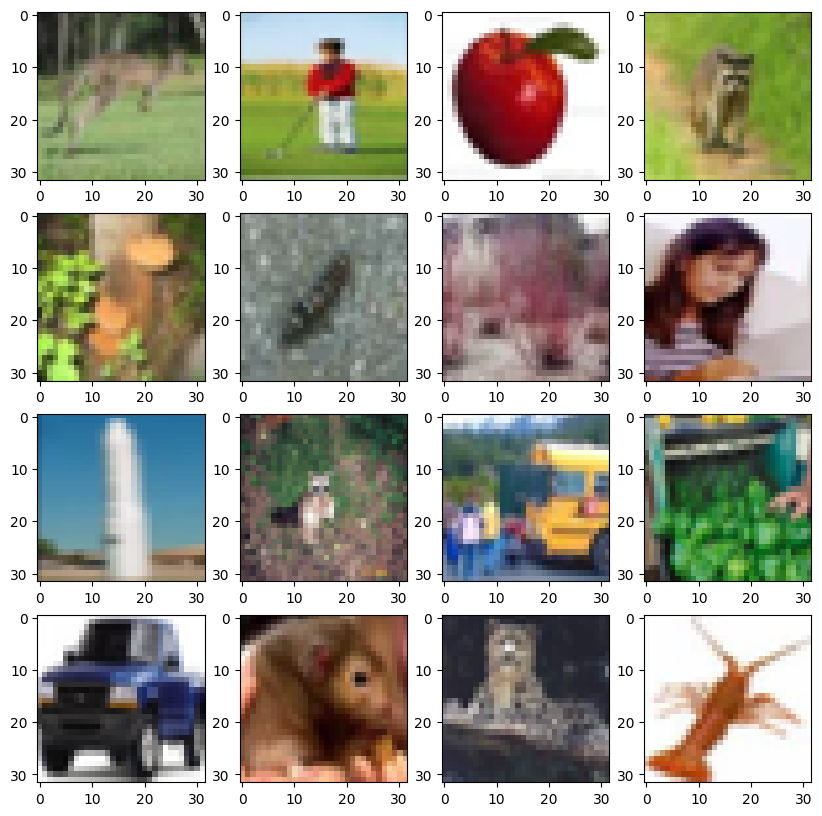

In [3]:
# Show randomly 16 images in the CIFAR-100
plt.figure(figsize=(10, 10))
for i in range (16):
  rand_num = np.random.randint(0, 50000)
  cifar_img = plt.subplot(4,4, i+1)
  plt.imshow(x_train[rand_num])

In [4]:
# Import libraries for preprocessing images
from tensorflow.keras.utils import to_categorical

# Normalize images
train_images = x_train.astype('float32')/255
test_images = x_test.astype('float32')/255

# Transform labels to one hot encoding
train_labels = to_categorical(y_train)
test_labels = to_categorical(y_test)

In [5]:
from keras.models import Sequential
from keras.layers import MaxPooling2D, Conv2D, Flatten, Dense, Activation, Dropout

In [6]:
# Plot function for visualisation training process
import matplotlib.pyplot as plt

def training_plot(history):
  acc = history.history['acc']
  val_acc = history.history['val_acc']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, 'bo', label='Training acc')
  plt.plot(epochs, val_acc, 'b', label='Validation acc')
  plt.title('Training and validation accuracy')
  plt.legend()
  plt.figure()
  plt.plot(epochs, loss, 'bo', label='Training loss')
  plt.plot(epochs, val_loss, 'b', label='Validation loss')
  plt.title('Training and validation loss')
  plt.legend()
  plt.show()

In [7]:
# Build CNN model with increase of filters
model = Sequential()
model.add(Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Add a classifier on top of CNN
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(100, activation='softmax'))

model.summary()

# Configure the model for training
from tensorflow.keras import optimizers
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 537,188 (2.05 MB)

 Trainable params: 537,188 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Configure the model for training
from tensorflow.keras import optimizers
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

In [9]:
# Training and testing model
import time
training_start = time.time()
history = model.fit(train_images, train_labels,
                    steps_per_epoch=100,
                    epochs=100,
                    validation_split=0.2) # 20% of training set is used for validation
training_stop = time.time()
training_time = training_stop - training_start
print(f"Training time: {training_time}")

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - acc: 0.0179 - loss: 4.5884 - val_acc: 0.0336 - val_loss: 4.5483
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - acc: 0.0410 - loss: 4.4101 - val_acc: 0.0537 - val_loss: 4.2818
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.0619 - loss: 4.2116 - val_acc: 0.0738 - val_loss: 4.1648
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - acc: 0.0785 - loss: 4.1169 - val_acc: 0.0908 - val_loss: 4.0854
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - acc: 0.0944 - loss: 4.0355 - val_acc: 0.0985 - val_loss: 4.0193
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - acc: 0.1081 - loss: 3.9575 - val_acc: 0.1124 - val_loss: 3.9467
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.1195 - loss: 3.8840 - val_acc: 0.1221 - val_loss: 3.8687
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - acc: 0.1280 - loss: 3.8203 - val_acc: 0.1295 - val_loss: 3.8184
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━

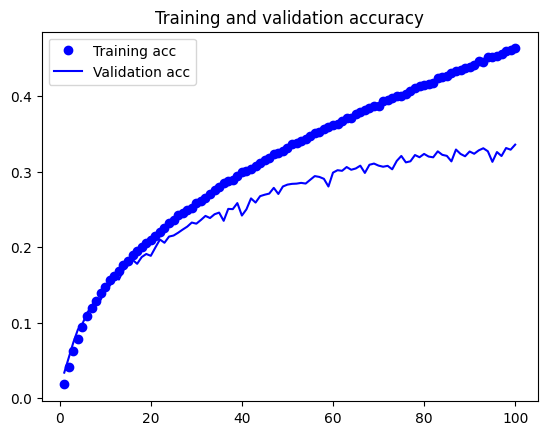

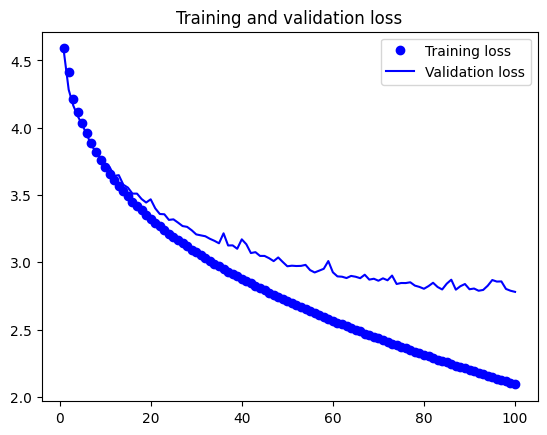

In [10]:
training_plot(history)

In [11]:
scores = model.evaluate(test_images, test_labels)
print(f'accuracy on test set: {model.metrics_names[1]} of {scores[1]*100}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.3406 - loss: 2.7577
accuracy on test set: compile_metrics of 34.060001373291016


In [13]:
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_labels, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


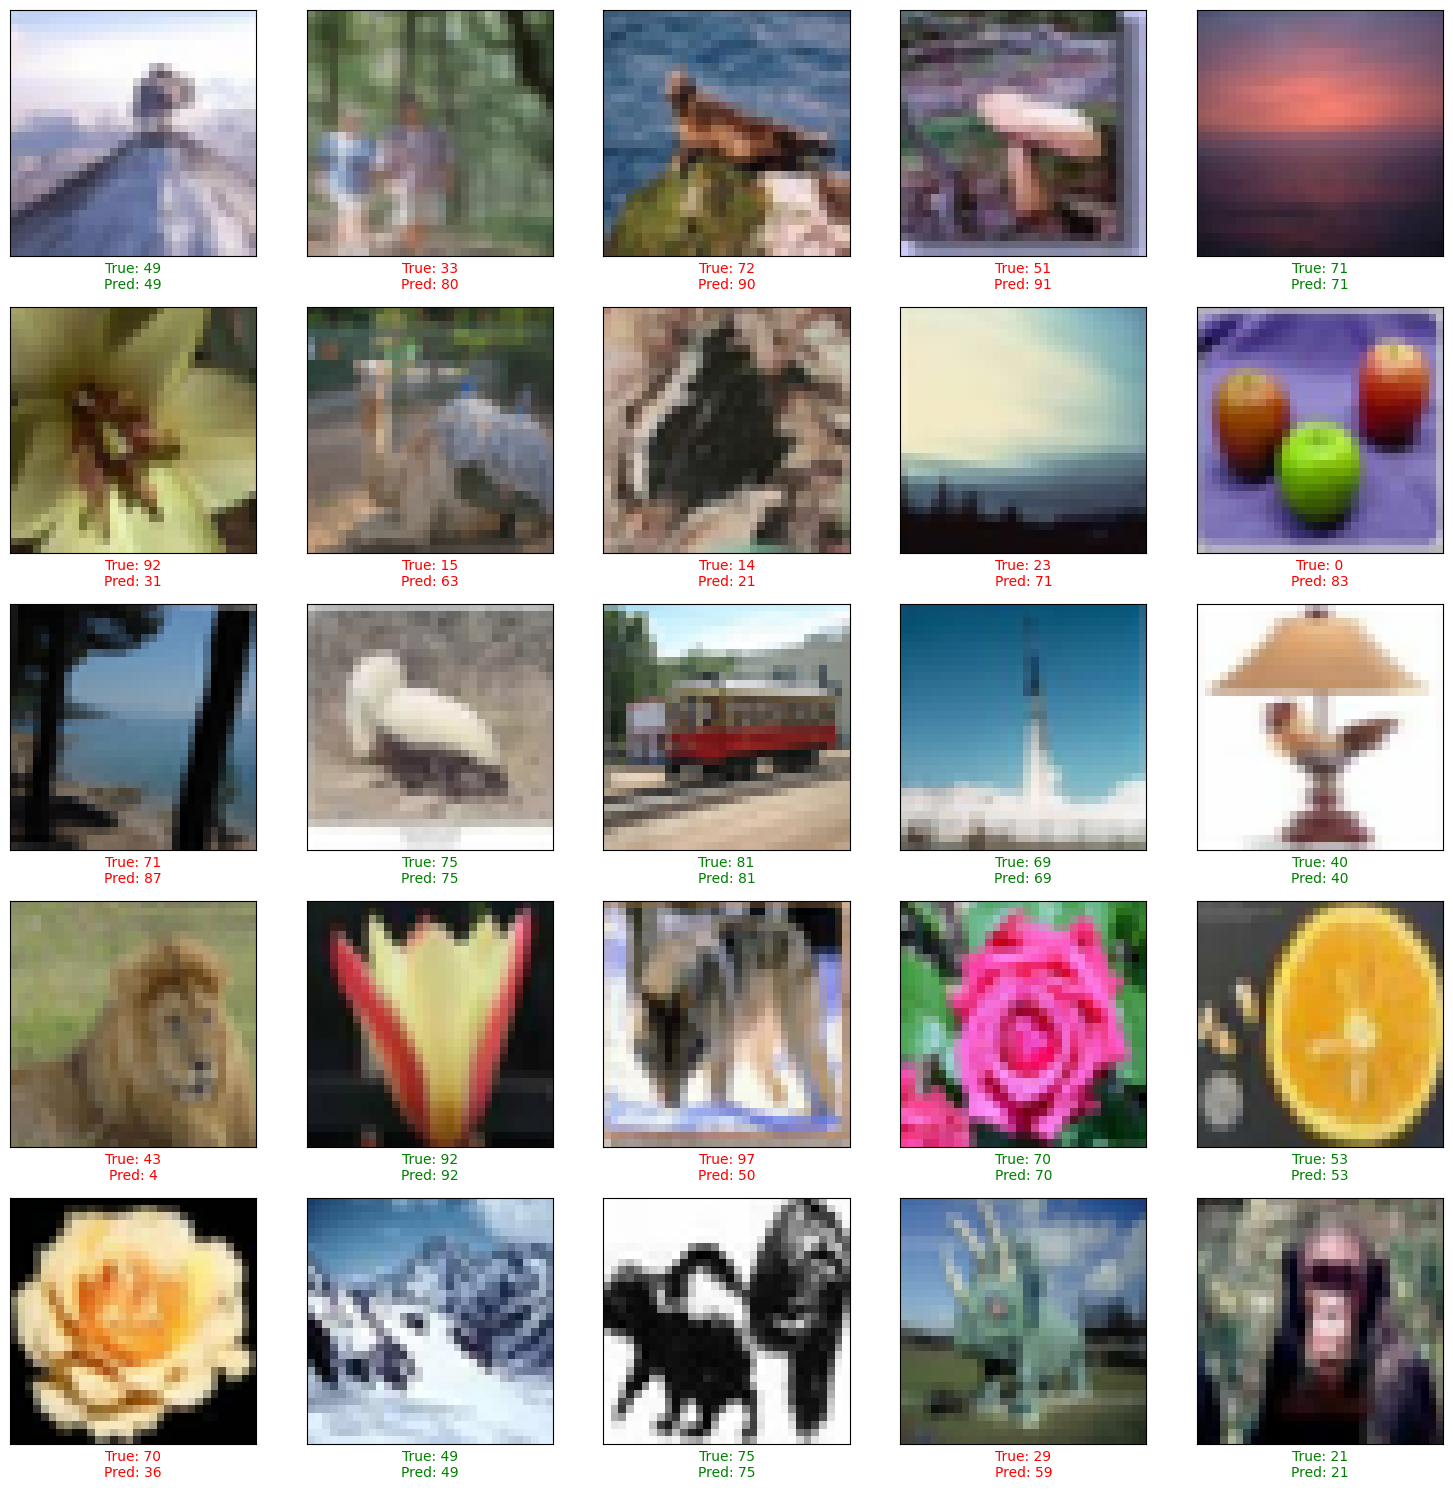

In [14]:
# Plotting a few test images with predicted and actual labels
plt.figure(figsize=(15, 15))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)

    true_label = y_true_classes[i]
    predicted_label = y_pred_classes[i]

    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.xlabel(f"True: {true_label}\nPred: {predicted_label}", color=color)
plt.tight_layout()
plt.show()